[Course material - Sustain.Brussels - "Avdanced AI workflows with LLM" - 20/04/2026 - 22/04/2026](https://github.com/Yannael/gen-ai-sustain-brussels-2604).

# How GPT-2 Works: A Simple Tutorial

This notebook walks through the basics of GPT-2 — how it's downloaded from HuggingFace, how it tokenizes text, and how it generates completions step by step.

Model is at https://huggingface.co/openai-community/gpt2

**What we'll cover:**
1. Installing dependencies
2. Downloading GPT-2 from HuggingFace
3. Tokenization: how text becomes numbers
4. Greedy decoding: completing "my name is"
5. Sampling strategies: temperature, top-k, top-p
6. Visualizing token probabilities

## 1. Install dependencies

We need `transformers` (HuggingFace), `torch`, and `matplotlib` for visualization.

In [ ]:
# Run once to install dependencies
!pip install transformers torch matplotlib --quiet

## 2. Download GPT-2 from HuggingFace

GPT-2 is an autoregressive language model from OpenAI (2019). HuggingFace hosts the weights publicly. The `AutoTokenizer` and `AutoModelForCausalLM` classes handle downloading and caching automatically.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "gpt2"  # ~500MB, smallest variant

print(f"Downloading tokenizer and model '{MODEL_NAME}' from HuggingFace...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval()  # disable dropout for deterministic outputs

print(f"\nModel loaded!")
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Vocab size : {tokenizer.vocab_size:,}")
print(f"  Max context: {model.config.n_ctx} tokens")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model loaded!
  Parameters : 124,439,808
  Vocab size : 50,257
  Max context: 1024 tokens


In [ ]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

## 3. Tokenization: text → numbers

GPT-2 uses **Byte-Pair Encoding (BPE)**. Words are split into subword pieces. Each piece maps to an integer ID that the model understands.

In [ ]:
prompt = "my name is"

# Encode the prompt
input_ids = tokenizer.encode(prompt, return_tensors="pt")

print(f"Prompt : '{prompt}'")
print(f"Token IDs: {input_ids[0].tolist()}")
print()

# Show each token and its string representation
print("Token breakdown:")
print(f"{'ID':>6}  Token")
print("-" * 20)
for token_id in input_ids[0].tolist():
    token_str = tokenizer.decode([token_id])
    print(f"{token_id:>6}  '{token_str}'")

Prompt : 'my name is'
Token IDs: [1820, 1438, 318]

Token breakdown:
    ID  Token
--------------------
  1820  'my'
  1438  ' name'
   318  ' is'


## 4. One forward pass: what does the model predict next?

GPT-2 takes a sequence of token IDs and outputs a **logit score** for every vocabulary token. The highest-scoring token is the model's best guess for what comes next.

In [ ]:
import torch.nn.functional as F

with torch.no_grad():
    outputs = model(input_ids)

# outputs.logits shape: (batch, sequence_length, vocab_size)
logits = outputs.logits  # raw scores
next_token_logits = logits[0, -1, :]  # logits for the NEXT token

# Convert logits → probabilities
probs = F.softmax(next_token_logits, dim=-1)

# Top-10 predictions
top_probs, top_ids = torch.topk(probs, 10)

print(f"Top 10 predicted next tokens after '{prompt}':")
print(f"{'Rank':>4}  {'Token':>15}  {'Prob':>8}")
print("-" * 35)
for rank, (prob, token_id) in enumerate(zip(top_probs, top_ids), 1):
    token_str = tokenizer.decode([token_id.item()])
    print(f"{rank:>4}  {repr(token_str):>15}  {prob.item():.4f}")

Top 10 predicted next tokens after 'my name is':
Rank            Token      Prob
-----------------------------------
   1             ' a'  0.0186
   2           ' the'  0.0155
   3           ' not'  0.0144
   4             ' "'  0.0098
   5          ' John'  0.0073
   6              ','  0.0067
   7             " '"  0.0059
   8            ' my'  0.0055
   9            ' in'  0.0054
  10         ' James'  0.0050


## 5. Greedy decoding: always pick the top token

The simplest generation strategy is **greedy decoding** — append the highest-probability token, then feed the updated sequence back in, repeat.

In [ ]:
def greedy_decode(prompt, max_new_tokens=20):
    ids = tokenizer.encode(prompt, return_tensors="pt")
    generated = []

    with torch.no_grad():
        for step in range(max_new_tokens):
            logits = model(ids).logits[0, -1, :]
            next_id = logits.argmax().item()
            next_token = tokenizer.decode([next_id])
            generated.append(next_token)
            ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)

            # Stop at end-of-sequence
            if next_id == tokenizer.eos_token_id:
                break

    completion = "".join(generated)
    return completion


prompt = "my name is"
completion = greedy_decode(prompt, max_new_tokens=20)

print(f"Prompt    : '{prompt}'")
print(f"Completion: '{completion}'")
print(f"Full text : '{prompt}{completion}'")

Prompt    : 'my name is'
Completion: ' a little bit different. I'm a little bit more of a guy who likes to play with his'
Full text : 'my name is a little bit different. I'm a little bit more of a guy who likes to play with his'


## 6. Using `model.generate()` — the HuggingFace way

In practice, use the built-in `generate()` method which supports many decoding strategies.

In [ ]:
prompt = "my name is"
input_ids = tokenizer.encode(prompt, return_tensors="pt")

# --- Greedy ---
greedy_ids = model.generate(input_ids, max_new_tokens=20, do_sample=False)
greedy_text = tokenizer.decode(greedy_ids[0], skip_special_tokens=True)

# --- Temperature sampling (more creative) ---
torch.manual_seed(42)
sampled_ids = model.generate(
    input_ids, max_new_tokens=20, do_sample=True, temperature=0.8
)
sampled_text = tokenizer.decode(sampled_ids[0], skip_special_tokens=True)

# --- Top-p (nucleus) sampling ---
torch.manual_seed(42)
nucleus_ids = model.generate(
    input_ids, max_new_tokens=20, do_sample=True, top_p=0.9, temperature=0.9
)
nucleus_text = tokenizer.decode(nucleus_ids[0], skip_special_tokens=True)

print("Greedy          :", greedy_text)
print("Temperature=0.8 :", sampled_text)
print("Top-p=0.9       :", nucleus_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Greedy          : my name is a little bit different. I'm a little bit more of a guy who likes to play with his
Temperature=0.8 : my name is Joffrey and I'm in shock."

The former Star Wars character and star of the
Top-p=0.9       : my name is Joffrey and I'm in charge. If you wanna go see something then come on over and


## 7. Visualizing next-token probabilities

Let's plot the probability distribution over the top candidates after "my name is".

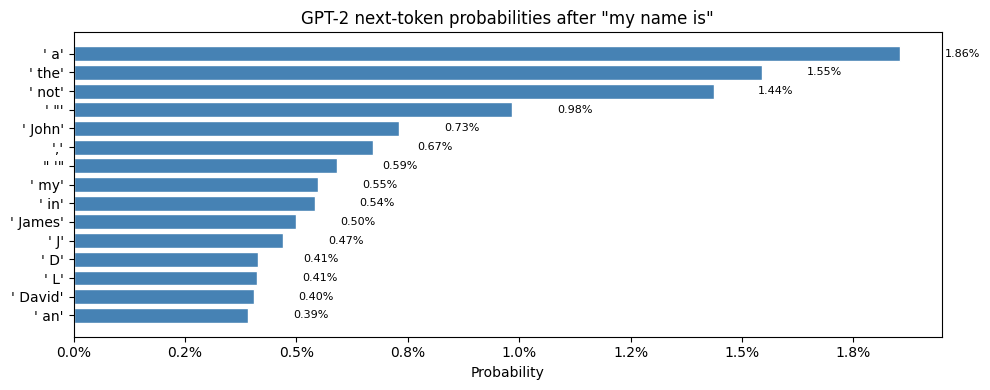

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

prompt = "my name is"
input_ids = tokenizer.encode(prompt, return_tensors="pt")

with torch.no_grad():
    logits = model(input_ids).logits[0, -1, :]

probs = F.softmax(logits, dim=-1)
top_probs, top_ids = torch.topk(probs, 15)

labels = [repr(tokenizer.decode([i.item()])) for i in top_ids]
values = top_probs.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels[::-1], values[::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Probability")
ax.set_title(f'GPT-2 next-token probabilities after "{prompt}"')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
for bar, val in zip(bars, values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.2%}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Step-by-step generation trace

Let's watch the model build the sentence token-by-token, printing the top-3 candidates at each step.

In [ ]:
def generation_trace(prompt, max_new_tokens=10):
    ids = tokenizer.encode(prompt, return_tensors="pt")
    context = prompt

    print(f"Starting prompt: '{prompt}'\n")
    print(f"{'Step':>4}  {'Chosen':>12}  Top-3 alternatives")
    print("-" * 60)

    with torch.no_grad():
        for step in range(max_new_tokens):
            logits = model(ids).logits[0, -1, :]
            probs = F.softmax(logits, dim=-1)
            top_probs, top_ids = torch.topk(probs, 3)

            chosen_id = top_ids[0].item()
            chosen_str = tokenizer.decode([chosen_id])
            alts = [
                f"{repr(tokenizer.decode([top_ids[i].item()]))} ({top_probs[i].item():.1%})"
                for i in range(3)
            ]
            print(f"{step+1:>4}  {repr(chosen_str):>12}  {' | '.join(alts)}")

            ids = torch.cat([ids, torch.tensor([[chosen_id]])], dim=1)
            context += chosen_str

            if chosen_id == tokenizer.eos_token_id:
                break

    print(f"\nFinal: '{context}'")


generation_trace("my name is", max_new_tokens=10)

Starting prompt: 'my name is'

Step        Chosen  Top-3 alternatives
------------------------------------------------------------
   1          ' a'  ' a' (1.9%) | ' the' (1.5%) | ' not' (1.4%)
   2     ' little'  ' little' (2.0%) | ' bit' (1.6%) | ' pseudonym' (1.3%)
   3        ' bit'  ' bit' (14.1%) | ' different' (6.6%) | ' more' (4.0%)
   4  ' different'  ' different' (13.3%) | ' of' (13.2%) | ' more' (6.2%)
   5           '.'  '.' (20.0%) | ' from' (17.1%) | ',' (15.2%)
   6          ' I'  ' I' (22.6%) | '\n' (14.3%) | ' It' (5.8%)
   7          "'m"  "'m" (19.2%) | ' think' (6.4%) | "'ve" (5.9%)
   8          ' a'  ' a' (15.1%) | ' not' (15.0%) | ' from' (4.5%)
   9     ' little'  ' little' (5.4%) | ' big' (4.3%) | ' bit' (3.3%)
  10        ' bit'  ' bit' (45.1%) | ' more' (11.5%) | ' different' (4.5%)

Final: 'my name is a little bit different. I'm a little bit'


## 9. More prompts to explore

Try different starting phrases and compare how GPT-2 completes them.

In [ ]:
prompts = [
    "my name is",
    "The capital of France is",
    "What is your name ?",
    "What is the capital of France ?",
    "What is your favorite color ?",
]

for p in prompts:
    ids = tokenizer.encode(p, return_tensors="pt")
    torch.manual_seed(0)
    out = model.generate(ids, max_new_tokens=25, do_sample=True, temperature=0.7,
                         top_p=0.9, pad_token_id=tokenizer.eos_token_id)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    print(f">>> {text}")
    print()

>>> my name is a guy named Bob," said Bob, "and he's the man that gave me the idea for the book. He's

>>> The capital of France is a place that has never had much of a French culture, but it has had a strong culture of people who have been raised

>>> What is your name ?

Michele M.

Michele M.

Michele M.

Miche

>>> What is the capital of France ?

The capital of France is the capital of France.

In the city of Paris, the capital is the city

>>> What is your favorite color ?

I love the color of my hair. I love the way it flows, and the way it looks. I love



## Summary

| Concept | What it does |
|---|---|
| **BPE tokenizer** | Splits text into subword pieces, maps each to an integer ID |
| **Forward pass** | Feeds token IDs through transformer layers, outputs logits over vocab |
| **Softmax** | Converts logits to probabilities |
| **Greedy decoding** | Always picks the highest-probability token |
| **Temperature** | Sharpens (< 1) or flattens (> 1) the probability distribution |
| **Top-p sampling** | Samples only from the smallest set of tokens whose cumulative prob ≥ p |

GPT-2 has no knowledge of "intent" — it simply predicts the next token based on patterns learned from ~40 GB of internet text. That's all there is to it!